# Demand Forecasting Model

**Goal:** Forecast quarterly openings demand for each Region × Role Cluster combo, then allocate to locations.

**Architecture:**
- **Tier 1** (≥30/qtr): SARIMAX with exogenous variables (UNRATE, quarter dummies, lagged fills)
- **Tier 2** (10-30/qtr): Exponential Smoothing (simpler, avoids overfitting thin data)
- **7 full-granularity segments**: Direct location-level forecast (no allocation needed)

**Validation:** Train on 2022Q1-2025Q4, predict Q1+Q2 2026, compare to actuals.

**Output:** Region × Role × Location × Quarter forecast table with confidence intervals.

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load, Merge & Build Quarterly Time Series
#
# Build the quarterly openings SUM (not row count) for each
# of the 51 Region × Role combos.
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load datasets
df = pd.read_pickle(os.path.join(data_dir, 'clean_42k_v1.pkl'))
mapping = pd.read_pickle(os.path.join(data_dir, 'title_to_cluster.pkl'))

# Join role_cluster
title_to_role = dict(zip(mapping['raw_title'], mapping['role_cluster']))
df['role_cluster'] = df['title'].map(title_to_role)
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['quarter'] = df['issue_date'].dt.to_period('Q')
df['location'] = df['location'].fillna('Unknown')
df['combo_key'] = df['region'] + ' | ' + df['role_cluster']

# Ensure openings is numeric
df['openings'] = pd.to_numeric(df['openings'], errors='coerce').fillna(1)
df['fills'] = pd.to_numeric(df['fills'], errors='coerce').fillna(0)

# Build quarterly time series: SUM of openings per combo per quarter
ts_data = (
    df.groupby(['combo_key', 'region', 'role_cluster', 'quarter'])
    .agg(openings=('openings', 'sum'), fills=('fills', 'sum'), record_count=('title', 'count'))
    .reset_index()
)

# Identify the 51 viable combos (≥10 avg records/quarter in training window)
train_start = pd.Period('2022Q1', freq='Q')
train_end = pd.Period('2025Q4', freq='Q')
train_quarters = sorted([q for q in ts_data['quarter'].unique() if train_start <= q <= train_end])

ts_train = ts_data[ts_data['quarter'].isin(train_quarters)]
combo_avg = ts_train.groupby('combo_key')['record_count'].mean()
viable_combos = combo_avg[combo_avg >= 10].index.tolist()

# Tier classification
tier_map = {}
for combo in viable_combos:
    avg = combo_avg[combo]
    tier_map[combo] = 'Tier 1' if avg >= 30 else 'Tier 2'

print(f"Total records: {len(df):,}")
print(f"Training window: {train_start} → {train_end} ({len(train_quarters)} quarters)")
print(f"Viable combos: {len(viable_combos)}")
print(f"  Tier 1 (≥30/qtr, SARIMAX): {sum(1 for t in tier_map.values() if t == 'Tier 1')}")
print(f"  Tier 2 (10-30/qtr, ExpSmooth): {sum(1 for t in tier_map.values() if t == 'Tier 2')}")

# Also identify the 7 full-granularity Tier 1 segments (from NB03)
loc_ts = (
    df.groupby(['combo_key', 'location', 'quarter'])
    .agg(openings=('openings', 'sum'), fills=('fills', 'sum'))
    .reset_index()
)
loc_train = loc_ts[loc_ts['quarter'].isin(train_quarters)]
loc_avg = loc_train.groupby(['combo_key', 'location'])['openings'].mean()
full_gran_segments = loc_avg[loc_avg >= 30].reset_index()
full_gran_segments.columns = ['combo_key', 'location', 'avg_openings_per_qtr']

print(f"\nFull-granularity segments (location-level Tier 1): {len(full_gran_segments)}")
for _, seg in full_gran_segments.iterrows():
    print(f"  {seg['combo_key']} | {seg['location']} ({seg['avg_openings_per_qtr']:.0f}/qtr)")

# ── Extended training window (includes 2026 data for improved forecasts) ──
# Baseline window stays: train_quarters = 2022Q1-2025Q4 (for CV + Cell 8 validation)
train_quarters_baseline = list(train_quarters)  # freeze baseline

# Q2 2026 adjustment: data extracted June 5 → June only has 5 days (104 records)
# Full June extrapolated at Apr/May rate: ~624 records
# Scale factor: (651 + 644 + 624) / (651 + 644 + 104) ≈ 1.37
Q2_2026_SCALE = 1.37

# Create adjusted openings column (float for scaled values)
ts_data['openings_adj'] = ts_data['openings'].astype(float)
mask_2026q2 = (ts_data['quarter'] >= pd.Period('2026Q2', freq='Q')) & \
              (ts_data['quarter'] <= pd.Period('2026Q2', freq='Q'))
ts_data.loc[mask_2026q2, 'openings_adj'] = ts_data.loc[mask_2026q2, 'openings'].astype(float) * Q2_2026_SCALE

# Extended window for forecast generation (includes real 2026 trend data)
q1_2026 = pd.Period('2026Q1', freq='Q')
q2_2026_period = pd.Period('2026Q2', freq='Q')
train_quarters_extended = train_quarters_baseline + sorted([
    q for q in ts_data['quarter'].unique()
    if q >= q1_2026 and q <= q2_2026_period and q not in train_quarters_baseline
])

print(f"\n── Training Windows: ──")
print(f"  Baseline (CV/validation): {train_quarters_baseline[0]}–{train_quarters_baseline[-1]} ({len(train_quarters_baseline)}Q)")
print(f"  Extended (forecast gen):  {train_quarters_extended[0]}–{train_quarters_extended[-1]} ({len(train_quarters_extended)}Q)")
print(f"  Q2 2026 scale factor: {Q2_2026_SCALE:.2f} (adjusts for June 5 extraction cutoff)")

# Quick view of the time series for top combo
print(f"\n── Sample time series (top combo by volume): ──")
top_combo = combo_avg.idxmax()
sample_ts = ts_data[ts_data['combo_key'] == top_combo][['quarter', 'openings', 'fills']]
print(f"  {top_combo}:")
for _, row in sample_ts.tail(8).iterrows():
    print(f"    {row['quarter']}: openings={row['openings']:.0f}, fills={row['fills']:.0f}")

Total records: 42,016
Training window: 2022Q1 → 2025Q4 (16 quarters)
Viable combos: 51
  Tier 1 (≥30/qtr, SARIMAX): 26
  Tier 2 (10-30/qtr, ExpSmooth): 25

Full-granularity segments (location-level Tier 1): 11
  IN | Developer | Bangalore (58/qtr)
  IN | HR Operations | Hyderabad (35/qtr)
  IN | Java Developer (India) | Bangalore (45/qtr)
  IN | Java Developer (India) | Unknown (51/qtr)
  IN | Software Engineer | Pune (34/qtr)
  US | Engineering - General | CA (52/qtr)
  US | Operations - General | CA (34/qtr)
  US | Program Manager | CA (43/qtr)
  US | Program Manager | WA (55/qtr)
  US | Software Engineer | CA (35/qtr)
  US | Software Engineer | WA (50/qtr)

── Training Windows: ──
  Baseline (CV/validation): 2022Q1–2025Q4 (16Q)
  Extended (forecast gen):  2022Q1–2026Q2 (18Q)
  Q2 2026 scale factor: 1.37 (adjusts for June 5 extraction cutoff)

── Sample time series (top combo by volume): ──
  US | Engineering - General:
    2024Q3: openings=256, fills=22
    2024Q4: openings=253, fil

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Exogenous Variables
#
# 1. FRED UNRATE → quarterly average (US proxy, also used for IN)
# 2. Quarter dummies (Q1-Q4 seasonality)
# 3. Lagged fills (test lag 1-3, use best)
# ═══════════════════════════════════════════════════════════════

# ── 1. UNRATE: monthly → quarterly average ──
unrate = pd.read_csv(os.path.join(data_dir, 'UNRATE.csv'))
unrate['observation_date'] = pd.to_datetime(unrate['observation_date'])
unrate['UNRATE'] = pd.to_numeric(unrate['UNRATE'], errors='coerce')
unrate = unrate.dropna(subset=['UNRATE'])
unrate['quarter'] = unrate['observation_date'].dt.to_period('Q')

# Quarterly average
unrate_qtr = unrate.groupby('quarter')['UNRATE'].mean().reset_index()
unrate_qtr.columns = ['quarter', 'unrate']

print("── UNRATE (quarterly avg): ──")
for _, row in unrate_qtr.iterrows():
    print(f"  {row['quarter']}: {row['unrate']:.2f}")

# For Q3/Q4 2026 forecasts, extrapolate UNRATE (use latest known value)
latest_unrate = unrate_qtr['unrate'].iloc[-1]
future_quarters = [pd.Period('2026Q3', freq='Q'), pd.Period('2026Q4', freq='Q')]
for fq in future_quarters:
    if fq not in unrate_qtr['quarter'].values:
        unrate_qtr = pd.concat([unrate_qtr, pd.DataFrame({'quarter': [fq], 'unrate': [latest_unrate]})],
                               ignore_index=True)

print(f"\n  (Future quarters extrapolated at {latest_unrate:.2f})")

# ── 2. Quarter dummies ──
# Will be added per-combo when building the feature matrix

# ── 3. Lagged fills correlation check ──
# Test ALL 51 combos (cheap to compute), sorted by volume for reporting
top_combos_by_volume = combo_avg.sort_values(ascending=False).index.tolist()

print(f"\n── Fills-Openings Lag Correlation (all {len(viable_combos)} combos): ──")
print(f"{'Combo':<40} {'Lag1':<8} {'Lag2':<8} {'Lag3':<8} {'Best'}")
print("─"*70)

lag_results = {}
for combo in top_combos_by_volume:  # test all combos, sorted by volume
    combo_ts = ts_data[ts_data['combo_key'] == combo].sort_values('quarter').copy()
    if len(combo_ts) < 8:
        continue
    
    best_lag = 0
    best_corr = 0
    lag_corrs = []
    for lag in [1, 2, 3]:
        combo_ts[f'fills_lag{lag}'] = combo_ts['fills'].shift(lag)
        corr = combo_ts[['openings', f'fills_lag{lag}']].dropna().corr().iloc[0, 1]
        lag_corrs.append(corr)
        if abs(corr) > abs(best_corr):
            best_corr = corr
            best_lag = lag
    
    lag_results[combo] = {'best_lag': best_lag, 'best_corr': best_corr}
    print(f"{combo[:39]:<40} {lag_corrs[0]:>+.3f}  {lag_corrs[1]:>+.3f}  {lag_corrs[2]:>+.3f}  lag{best_lag}({best_corr:+.3f})")

# Decision: use fills_lag1 as exogenous where |corr| > 0.2
use_fills_lag = {k: v['best_lag'] for k, v in lag_results.items() if abs(v['best_corr']) > 0.2}
print(f"\n→ Using lagged fills for {len(use_fills_lag)} combos (|corr| > 0.2)")
print(f"→ UNRATE used as macro proxy for all combos (US data; limitation noted for India)")

── UNRATE (quarterly avg): ──
  2022Q1: 3.87
  2022Q2: 3.63
  2022Q3: 3.53
  2022Q4: 3.57
  2023Q1: 3.53
  2023Q2: 3.53
  2023Q3: 3.63
  2023Q4: 3.80
  2024Q1: 3.83
  2024Q2: 3.97
  2024Q3: 4.17
  2024Q4: 4.13
  2025Q1: 4.13
  2025Q2: 4.20
  2025Q3: 4.33
  2025Q4: 4.45
  2026Q1: 4.33
  2026Q2: 4.30

  (Future quarters extrapolated at 4.30)

── Fills-Openings Lag Correlation (all 51 combos): ──
Combo                                    Lag1     Lag2     Lag3     Best
──────────────────────────────────────────────────────────────────────
US | Engineering - General               +0.815  +0.718  +0.646  lag1(+0.815)
US | Operations - General                +0.654  +0.534  +0.540  lag1(+0.654)
US | Program Manager                     +0.748  +0.749  +0.515  lag2(+0.749)
US | Software Engineer                   +0.692  +0.585  +0.481  lag1(+0.692)
US | Project Manager                     +0.500  +0.438  +0.267  lag1(+0.500)
US | Developer                           +0.333  +0.157  +0.034  lag1

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Model Fitting: SARIMAX (Tier 1) + ExpSmooth (Tier 2)
#
# For each combo: fit on full training window (2022Q1-2025Q4)
# Store fitted models for forecasting and CV.
# ═══════════════════════════════════════════════════════════════
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def build_features(combo_ts, unrate_qtr, use_fills=False, fills_lag=1):
    """Build exogenous feature matrix for a combo time series."""
    combo_ts = combo_ts.sort_values('quarter').copy()
    
    # Merge UNRATE
    combo_ts = combo_ts.merge(unrate_qtr, on='quarter', how='left')
    # Forward-fill any missing UNRATE (shouldn't happen within training)
    combo_ts['unrate'] = combo_ts['unrate'].ffill().bfill()
    
    # Quarter dummies
    combo_ts['q_num'] = combo_ts['quarter'].apply(lambda x: x.quarter)
    for q in [1, 2, 3]:  # Q4 is reference
        combo_ts[f'Q{q}'] = (combo_ts['q_num'] == q).astype(int)
    
    # Lagged fills
    if use_fills:
        combo_ts['fills_lagged'] = combo_ts['fills'].shift(fills_lag)
    
    return combo_ts


def get_exog_cols(use_fills=False):
    """Return list of exogenous column names."""
    cols = ['unrate', 'Q1', 'Q2', 'Q3']
    if use_fills:
        cols.append('fills_lagged')
    return cols


# Fit models for all 51 combos
models = {}  # {combo_key: {'model': fitted_model, 'tier': tier, ...}}
fit_errors = []

print("═"*70)
print("MODEL FITTING")
print("═"*70)
print(f"\nFitting {len(viable_combos)} models...")

for i, combo in enumerate(viable_combos):
    tier = tier_map[combo]
    combo_ts = ts_data[ts_data['combo_key'] == combo].copy()
    
    # Use fills lag?
    use_fills = combo in use_fills_lag
    fills_lag = use_fills_lag.get(combo, 1)
    
    # Build features
    combo_ts = build_features(combo_ts, unrate_qtr, use_fills=use_fills, fills_lag=fills_lag)
    
    # Filter to training window
    train = combo_ts[combo_ts['quarter'].isin(train_quarters)].copy()
    
    # Drop rows with NaN in exog (from lagging)
    exog_cols = get_exog_cols(use_fills=use_fills)
    train = train.dropna(subset=exog_cols + ['openings'])
    
    if len(train) < 6:  # need minimum observations
        fit_errors.append((combo, 'Too few observations'))
        continue
    
    y = train['openings'].values.astype(float)
    
    try:
        if tier == 'Tier 1':
            # SARIMAX(1,0,1) with exogenous — no differencing (short series)
            X = train[exog_cols].values.astype(float)
            model = SARIMAX(
                y, exog=X,
                order=(1, 0, 1),
                seasonal_order=(0, 0, 0, 0),  # no seasonal ARIMA (too few points)
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200)
            models[combo] = {
                'model': fitted,
                'tier': tier,
                'exog_cols': exog_cols,
                'use_fills': use_fills,
                'fills_lag': fills_lag,
                'train_data': train,
                'aic': fitted.aic,
            }
        else:
            # Exponential Smoothing — additive trend, no seasonality
            model = ExponentialSmoothing(
                y,
                trend='add',
                seasonal=None,
                damped_trend=True,
            )
            fitted = model.fit(optimized=True)
            models[combo] = {
                'model': fitted,
                'tier': tier,
                'exog_cols': [],
                'use_fills': False,
                'fills_lag': 0,
                'train_data': train,
                'aic': fitted.aic,
            }
    except Exception as e:
        fit_errors.append((combo, str(e)[:60]))

print(f"\n✅ Successfully fitted: {len(models)} / {len(viable_combos)}")
if fit_errors:
    print(f"⚠️  Fit errors: {len(fit_errors)}")
    for combo, err in fit_errors[:5]:
        print(f"    {combo}: {err}")

# Summary by tier
t1_fitted = sum(1 for m in models.values() if m['tier'] == 'Tier 1')
t2_fitted = sum(1 for m in models.values() if m['tier'] == 'Tier 2')
print(f"\n  Tier 1 (SARIMAX): {t1_fitted} fitted")
print(f"  Tier 2 (ExpSmooth): {t2_fitted} fitted")

# ═══════════════════════════════════════════════════════════════
# RECENCY RATIOS + FORECAST MODELS (separate from baseline)
# ═══════════════════════════════════════════════════════════════

# Compute recency ratio per combo: last 2Q (2026Q1 + Q2 adj) vs prior 4Q (2025Q1-Q4)
recency_ratios = {}
for combo in viable_combos:
    combo_ts = ts_data[ts_data['combo_key'] == combo].sort_values('quarter')
    extended = combo_ts[combo_ts['quarter'].isin(train_quarters_extended)]
    if len(extended) < 6:
        continue
    last_2 = extended['openings_adj'].iloc[-2:].mean()   # 2026Q1 + 2026Q2(adj)
    prior_4 = extended['openings_adj'].iloc[-6:-2].mean()  # 2025Q1-Q4
    recency_ratios[combo] = last_2 / prior_4 if prior_4 > 0 else np.nan

# Group classification
forecast_group = {}
for combo, ratio in recency_ratios.items():
    if np.isnan(ratio):
        forecast_group[combo] = 'Group 1 - Stable'
    elif ratio >= 0.85:
        forecast_group[combo] = 'Group 1 - Stable'
    elif ratio >= 0.40:
        forecast_group[combo] = 'Group 2 - Moderate contraction'
    else:
        forecast_group[combo] = 'Group 3 - Severe collapse'

# Assign remaining combos without ratio to Group 1
for combo in viable_combos:
    if combo not in forecast_group:
        forecast_group[combo] = 'Group 1 - Stable'

print(f"\n{'═'*70}")
print("RECENCY-BASED FORECAST GROUPS")
print(f"{'═'*70}")
g1 = sum(1 for g in forecast_group.values() if 'Group 1' in g)
g2 = sum(1 for g in forecast_group.values() if 'Group 2' in g)
g3 = sum(1 for g in forecast_group.values() if 'Group 3' in g)
print(f"  Group 1 — Stable (ratio ≥ 0.85):       {g1} combos → full-history model")
print(f"  Group 2 — Moderate contraction (0.40–0.85): {g2} combos → recent-window model (10-12Q)")
print(f"  Group 3 — Severe collapse (< 0.40):     {g3} combos → last-2Q average override")

# Build forecast models (separate from baseline `models` dict)
forecast_models = {}
forecast_fit_errors = []

for combo in viable_combos:
    if combo not in models:
        continue
    info = models[combo]
    group = forecast_group.get(combo, 'Group 1 - Stable')
    tier = info['tier']

    if 'Group 3' in group:
        continue  # handled via group3_overrides below

    combo_ts = ts_data[ts_data['combo_key'] == combo].copy()
    combo_ts = build_features(combo_ts, unrate_qtr, use_fills=info['use_fills'], fills_lag=info['fills_lag'])

    if 'Group 1' in group:
        fit_window = train_quarters_extended
    else:  # Group 2
        fit_window = train_quarters_extended[-11:]  # most recent 10-12 quarters

    train_fc = combo_ts[combo_ts['quarter'].isin(fit_window)].copy()
    exog_cols = get_exog_cols(use_fills=info['use_fills'])
    train_fc = train_fc.dropna(subset=exog_cols + ['openings_adj'])

    if len(train_fc) < 5:
        forecast_fit_errors.append((combo, 'Too few obs in extended window'))
        continue

    y_fc = train_fc['openings_adj'].values.astype(float)

    try:
        if tier == 'Tier 1':
            X_fc = train_fc[exog_cols].values.astype(float)
            m = SARIMAX(y_fc, exog=X_fc, order=(1, 0, 1),
                       enforce_stationarity=False, enforce_invertibility=False)
            f = m.fit(disp=False, maxiter=200)
        else:
            m = ExponentialSmoothing(y_fc, trend='add', seasonal=None, damped_trend=True)
            f = m.fit(optimized=True)

        forecast_models[combo] = {
            **info,
            'model': f,
            'train_data': train_fc,
            'group': group,
        }
    except Exception as e:
        forecast_fit_errors.append((combo, str(e)[:50]))

# Group 3 overrides — just use last-2Q adjusted average
group3_overrides = {}
for combo, group in forecast_group.items():
    if 'Group 3' in group:
        combo_ts = ts_data[ts_data['combo_key'] == combo].sort_values('quarter')
        extended = combo_ts[combo_ts['quarter'].isin(train_quarters_extended)]
        if len(extended) >= 2:
            group3_overrides[combo] = extended['openings_adj'].iloc[-2:].mean()
        else:
            group3_overrides[combo] = combo_ts['openings_adj'].iloc[-1] if len(combo_ts) > 0 else 0

print(f"\n  Forecast models fitted: {len(forecast_models)} (Group 1+2)")
print(f"  Group 3 overrides: {len(group3_overrides)} combos")
if forecast_fit_errors:
    print(f"  ⚠️  Fit errors: {len(forecast_fit_errors)}")
    for c, e in forecast_fit_errors[:3]:
        print(f"      {c}: {e}")

══════════════════════════════════════════════════════════════════════
MODEL FITTING
══════════════════════════════════════════════════════════════════════

Fitting 51 models...

✅ Successfully fitted: 51 / 51

  Tier 1 (SARIMAX): 26 fitted
  Tier 2 (ExpSmooth): 25 fitted

══════════════════════════════════════════════════════════════════════
RECENCY-BASED FORECAST GROUPS
══════════════════════════════════════════════════════════════════════
  Group 1 — Stable (ratio ≥ 0.85):       22 combos → full-history model
  Group 2 — Moderate contraction (0.40–0.85): 22 combos → recent-window model (10-12Q)
  Group 3 — Severe collapse (< 0.40):     7 combos → last-2Q average override

✅ Successfully fitted: 51 / 51

  Tier 1 (SARIMAX): 26 fitted
  Tier 2 (ExpSmooth): 25 fitted

══════════════════════════════════════════════════════════════════════
RECENCY-BASED FORECAST GROUPS
══════════════════════════════════════════════════════════════════════
  Group 1 — Stable (ratio ≥ 0.85):       22 combo

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Expanding Window Cross-Validation
#
# Train on first N quarters, predict N+1, expand window.
# Start with 8 quarters (2022Q1-2023Q4) as minimum train.
# Report MAPE, MAE, MASE per combo.
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import mean_absolute_error

MIN_TRAIN = 8  # minimum 8 quarters before first prediction

cv_results = []

print("Running expanding window CV...")
for combo in models:
    info = models[combo]
    tier = info['tier']
    train_full = info['train_data'].sort_values('quarter').copy()
    exog_cols = info['exog_cols']
    
    y_full = train_full['openings'].values.astype(float)
    n_obs = len(y_full)
    
    if n_obs < MIN_TRAIN + 2:  # need at least 2 CV folds
        continue
    
    actuals = []
    predictions = []
    
    for split in range(MIN_TRAIN, n_obs):
        y_train = y_full[:split]
        y_true = y_full[split]
        
        try:
            if tier == 'Tier 1':
                X_train = train_full[exog_cols].values[:split].astype(float)
                X_test = train_full[exog_cols].values[split:split+1].astype(float)
                
                m = SARIMAX(y_train, exog=X_train,
                           order=(1, 0, 1),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
                f = m.fit(disp=False, maxiter=100)
                pred = f.forecast(steps=1, exog=X_test)[0]
            else:
                m = ExponentialSmoothing(y_train, trend='add', damped_trend=True)
                f = m.fit(optimized=True)
                pred = f.forecast(steps=1)[0]
            
            # Guardrail: floor at 40% of recent avg, cap at 2.5×
            recent_avg = y_train[-4:].mean()
            pred = np.clip(pred, recent_avg * 0.4, recent_avg * 2.5)
            
            actuals.append(y_true)
            predictions.append(pred)
        except:
            continue
    
    if len(actuals) >= 2:
        actuals = np.array(actuals)
        predictions = np.array(predictions)
        
        mae = mean_absolute_error(actuals, predictions)
        mape = np.mean(np.abs((actuals - predictions) / np.maximum(actuals, 1))) * 100
        # MASE: MAE / naive forecast MAE (naive = last known value)
        naive_errors = np.abs(np.diff(y_full[MIN_TRAIN-1:]))
        mase = mae / naive_errors.mean() if naive_errors.mean() > 0 else np.inf
        
        cv_results.append({
            'combo_key': combo,
            'tier': tier,
            'n_folds': len(actuals),
            'mae': mae,
            'mape': mape,
            'mase': mase,
            'avg_actual': actuals.mean(),
        })

cv_df = pd.DataFrame(cv_results)

print(f"\n{'═'*70}")
print("CROSS-VALIDATION RESULTS")
print(f"{'═'*70}")
print(f"\nCombos evaluated: {len(cv_df)} / {len(models)}")
print(f"\n── Overall Metrics: ──")
print(f"  Median MAPE: {cv_df['mape'].median():.1f}%")
print(f"  Mean MAPE:   {cv_df['mape'].mean():.1f}%")
print(f"  Median MAE:  {cv_df['mae'].median():.1f} openings")
print(f"  Median MASE: {cv_df['mase'].median():.3f} (< 1.0 = better than naive)")

# By tier
print(f"\n── By Tier: ──")
for tier in ['Tier 1', 'Tier 2']:
    tier_cv = cv_df[cv_df['tier'] == tier]
    if len(tier_cv) > 0:
        print(f"  {tier}: median MAPE={tier_cv['mape'].median():.1f}%, "
              f"median MAE={tier_cv['mae'].median():.1f}, "
              f"median MASE={tier_cv['mase'].median():.3f}")

# Best and worst
print(f"\n── Top 5 best (lowest MAPE): ──")
for _, r in cv_df.nsmallest(5, 'mape').iterrows():
    print(f"  {r['combo_key'][:40]:<42} MAPE={r['mape']:>5.1f}%  MAE={r['mae']:>6.1f}")

print(f"\n── Top 5 worst (highest MAPE): ──")
for _, r in cv_df.nlargest(5, 'mape').iterrows():
    print(f"  {r['combo_key'][:40]:<42} MAPE={r['mape']:>5.1f}%  MAE={r['mae']:>6.1f}")

Running expanding window CV...

══════════════════════════════════════════════════════════════════════
CROSS-VALIDATION RESULTS
══════════════════════════════════════════════════════════════════════

Combos evaluated: 50 / 51

── Overall Metrics: ──
  Median MAPE: 48.8%
  Mean MAPE:   97.1%
  Median MAE:  15.9 openings
  Median MASE: 1.195 (< 1.0 = better than naive)

── By Tier: ──
  Tier 1: median MAPE=42.9%, median MAE=25.8, median MASE=1.324
  Tier 2: median MAPE=55.5%, median MAE=8.7, median MASE=1.004

── Top 5 best (lowest MAPE): ──
  US | Scientist                             MAPE= 14.6%  MAE=   5.9
  US | Finance & Accounting                  MAPE= 15.3%  MAE=   9.2
  US | Engineering - General                 MAPE= 18.7%  MAE=  38.5
  US | Program Manager                       MAPE= 22.7%  MAE=  28.0
  US | Software Engineer                     MAPE= 23.5%  MAE=  33.4

── Top 5 worst (highest MAPE): ──
  US | Java Developer (India)                MAPE=1305.7%  MAE=  44.4
  IN

In [28]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Generate Q3/Q4 2026 Forecasts (IMPROVED)
#
# Uses forecast_models (trained on extended window) for Group 1/2.
# Uses last-2Q override for Group 3 (severe collapse).
# Baseline models dict untouched (used by Cell 8 validation).
# ═══════════════════════════════════════════════════════════════

forecast_quarters = [pd.Period('2026Q3', freq='Q'), pd.Period('2026Q4', freq='Q')]

forecasts = []

for combo in viable_combos:
    if combo not in models:
        continue

    group = forecast_group.get(combo, 'Group 1 - Stable')
    tier = models[combo]['tier']

    # ── Group 3: override with last-2Q average ──
    if 'Group 3' in group:
        val = group3_overrides.get(combo, 0)
        for fq in forecast_quarters:
            forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': val,
                'ci_lower': val * 0.3,  # wide CI — high uncertainty
                'ci_upper': val * 1.7,
                'tier': tier,
                'forecast_method': 'Recent-trend override (severe contraction)',
            })
        continue

    # ── Group 1/2: use forecast_models ──
    if combo not in forecast_models:
        continue

    info = forecast_models[combo]
    fitted = info['model']
    train = info['train_data']
    method = 'Full-history model' if 'Group 1' in group else 'Recent-window model (10-12Q)'

    if tier == 'Tier 1':
        exog_cols = info['exog_cols']

        future_exog = []
        for fq in forecast_quarters:
            row = {}
            ur = unrate_qtr[unrate_qtr['quarter'] == fq]['unrate']
            row['unrate'] = ur.values[0] if len(ur) > 0 else latest_unrate
            row['Q1'] = 1 if fq.quarter == 1 else 0
            row['Q2'] = 1 if fq.quarter == 2 else 0
            row['Q3'] = 1 if fq.quarter == 3 else 0
            if info['use_fills']:
                row['fills_lagged'] = train['fills'].iloc[-1]
            future_exog.append(row)

        X_future = pd.DataFrame(future_exog)[exog_cols].values.astype(float)

        forecast_result = fitted.get_forecast(steps=2, exog=X_future)
        point = np.asarray(forecast_result.predicted_mean)
        ci = np.asarray(forecast_result.conf_int(alpha=0.20))

        for i, fq in enumerate(forecast_quarters):
            recent_avg = train['openings_adj'].iloc[-4:].mean()
            pred = np.clip(point[i], recent_avg * 0.4, recent_avg * 2.5)
            lo = max(recent_avg * 0.4, ci[i, 0])
            hi = min(recent_avg * 2.5, ci[i, 1])

            forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': pred,
                'ci_lower': lo,
                'ci_upper': hi,
                'tier': tier,
                'forecast_method': method,
            })
    else:
        # Tier 2: Exponential Smoothing
        point = np.asarray(fitted.forecast(steps=2))
        recent_avg = train['openings_adj'].iloc[-4:].mean()

        for i, fq in enumerate(forecast_quarters):
            pred = np.clip(point[i], recent_avg * 0.4, recent_avg * 2.5)
            lo = max(0, pred * 0.70)
            hi = pred * 1.30

            forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': pred,
                'ci_lower': lo,
                'ci_upper': hi,
                'tier': tier,
                'forecast_method': method,
            })

forecast_df = pd.DataFrame(forecasts)

# ── G2 FLOOR GUARDRAIL ──
# For Group 2 combos, the model shouldn't predict below 80% of the recent actual level.
# The recent level already reflects the contraction — don't let SARIMAX extrapolate further.
g2_floor_applied = 0
for combo in forecast_models:
    if forecast_group.get(combo) != 'Group 2 - Moderate contraction':
        continue
    extended = ts_data[(ts_data['combo_key'] == combo) &
                       (ts_data['quarter'].isin(train_quarters_extended))].sort_values('quarter')
    if len(extended) < 2:
        continue
    last_2_avg = extended['openings_adj'].iloc[-2:].mean()
    floor = last_2_avg * 0.80  # don't extrapolate decline beyond what's observed

    mask = forecast_df['combo_key'] == combo
    for idx in forecast_df[mask].index:
        if forecast_df.loc[idx, 'forecast'] < floor:
            forecast_df.loc[idx, 'forecast'] = floor
            forecast_df.loc[idx, 'forecast_method'] += ' (floored at recent-level)'
            # Rebuild CI around adjusted point
            forecast_df.loc[idx, 'ci_lower'] = floor * 0.85
            forecast_df.loc[idx, 'ci_upper'] = max(forecast_df.loc[idx, 'ci_upper'], floor * 1.15)
            g2_floor_applied += 1

print("═"*70)
print("Q3/Q4 2026 FORECASTS (Improved — recency-adjusted)")
print("═"*70)
print(f"\nTotal forecast rows: {len(forecast_df)} ({len(forecast_df)//2} combos × 2 quarters)")
print(f"  G2 floor applied: {g2_floor_applied} forecast rows adjusted")

# Identify which combos had floor applied (and how many quarters each)
floored_combos = forecast_df[forecast_df['forecast_method'].str.contains('floored', na=False)].groupby('combo_key').size()
if len(floored_combos) > 0:
    print(f"\n  Floor detail: {len(floored_combos)} combos floored")
    for combo, n_qtrs in floored_combos.items():
        print(f"    {combo[:40]}: {n_qtrs} quarter(s)")

# ── LOW-VOLUME FLAG ──
# Flag combos where forecast < 15 openings/quarter (point estimate unreliable at this scale)
LOW_VOL_THRESHOLD = 15
forecast_df['low_volume_flag'] = forecast_df['forecast'] < LOW_VOL_THRESHOLD
n_low_vol = forecast_df[forecast_df['low_volume_flag']].groupby('combo_key').size()
print(f"\n  Low-volume combos (forecast < {LOW_VOL_THRESHOLD}/qtr): {len(n_low_vol)}")
print(f"  (Point estimates for these have wide relative uncertainty — flagged in output)")

# ── DIAGNOSTIC: US | Operations-General (G1, ratio 1.088, but forecast dropped?) ──
ops_combo = 'US | Operations - General'
ops_ratio = recency_ratios.get(ops_combo, np.nan)
ops_group = forecast_group.get(ops_combo, '?')
ops_fc = forecast_df[(forecast_df['combo_key'] == ops_combo) &
                     (forecast_df['quarter'] == pd.Period('2026Q3'))]['forecast'].values
ops_extended = ts_data[(ts_data['combo_key'] == ops_combo) &
                       (ts_data['quarter'].isin(train_quarters_extended))].sort_values('quarter')
print(f"\n── Diagnostic: {ops_combo} ──")
print(f"  Recency ratio: {ops_ratio:.3f} (Group: {ops_group})")
print(f"  Last 4Q openings_adj: {ops_extended['openings_adj'].iloc[-4:].tolist()}")
print(f"  Q3 2026 forecast: {ops_fc[0]:.0f}" if len(ops_fc) > 0 else "  Q3 forecast: N/A")
print(f"  (Seasonality note: Q3 may just be low for this role historically)")

# Seasonal pattern check for Operations-General
ops_full = ts_data[ts_data['combo_key'] == ops_combo].copy()
ops_full['q_num'] = ops_full['quarter'].apply(lambda x: x.quarter)
seasonal_avg = ops_full.groupby('q_num')['openings'].mean()
print(f"  Historical quarterly avg: Q1={seasonal_avg.get(1,0):.0f}, Q2={seasonal_avg.get(2,0):.0f}, "
      f"Q3={seasonal_avg.get(3,0):.0f}, Q4={seasonal_avg.get(4,0):.0f}")

# By method
print(f"\n── By Forecast Method: ──")
for method, grp in forecast_df.groupby('forecast_method'):
    print(f"  {method}: {len(grp)//2} combos")

print(f"\n── Top 10 combos by forecasted Q3 2026 openings: ──")
q3_fc = forecast_df[forecast_df['quarter'] == pd.Period('2026Q3')].sort_values('forecast', ascending=False)
print(f"{'Combo':<38} {'Fcst':<7} {'80% CI':<16} {'Tier':<7} {'Method'}")
print("─"*90)
for _, r in q3_fc.head(10).iterrows():
    print(f"{r['combo_key'][:37]:<38} {r['forecast']:>5.0f}   "
          f"[{r['ci_lower']:.0f}–{r['ci_upper']:.0f}]{'':3} {r['tier']:<7} {r['forecast_method'][:35]}")

# ── G2 sanity check: forecast vs recency-ratio-implied level ──
print(f"\n── G2 Combos: Forecast vs Recency-Implied Level ──")
print(f"{'Combo':<38} {'Ratio':<7} {'Last2Q':<8} {'Floor':<7} {'Fcst':<7} {'Status'}")
print("─"*80)
for combo in sorted(forecast_models.keys()):
    if forecast_group.get(combo) != 'Group 2 - Moderate contraction':
        continue
    extended = ts_data[(ts_data['combo_key'] == combo) &
                       (ts_data['quarter'].isin(train_quarters_extended))].sort_values('quarter')
    if len(extended) < 2:
        continue
    last_2_avg = extended['openings_adj'].iloc[-2:].mean()
    floor = last_2_avg * 0.80
    ratio = recency_ratios.get(combo, np.nan)
    fc_row = forecast_df[(forecast_df['combo_key'] == combo) &
                         (forecast_df['quarter'] == pd.Period('2026Q3'))]
    fcst = fc_row['forecast'].values[0] if len(fc_row) > 0 else np.nan
    status = "✓" if fcst >= floor * 0.95 else "FLOORED"
    print(f"{combo[:37]:<38} {ratio:>5.3f}  {last_2_avg:>6.0f}  {floor:>5.0f}  {fcst:>5.0f}  {status}")

══════════════════════════════════════════════════════════════════════
Q3/Q4 2026 FORECASTS (Improved — recency-adjusted)
══════════════════════════════════════════════════════════════════════

Total forecast rows: 102 (51 combos × 2 quarters)
  G2 floor applied: 11 forecast rows adjusted

  Floor detail: 9 combos floored
    IN | Java Developer (India): 1 quarter(s)
    US | Business Systems Analyst: 1 quarter(s)
    US | Engineering - General: 2 quarter(s)
    US | Finance & Accounting: 1 quarter(s)
    US | Java Developer (India): 2 quarter(s)
    US | Program Manager: 1 quarter(s)
    US | Project Coordinator: 1 quarter(s)
    US | Software Engineer: 1 quarter(s)
    US | Technical Writer: 1 quarter(s)

  Low-volume combos (forecast < 15/qtr): 13
  (Point estimates for these have wide relative uncertainty — flagged in output)

── Diagnostic: US | Operations - General ──
  Recency ratio: 1.088 (Group: Group 1 - Stable)
  Last 4Q openings_adj: [125.0, 114.0, 208.0, 131.52]
  Q3 2026 

In [29]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Apply Location Allocation
#
# Join location_allocation.pkl onto forecasts.
# Multiply role-level forecast × location allocation %.
# Skip full-granularity segments (handled in Cell 7).
# ═══════════════════════════════════════════════════════════════

# Load allocation table
alloc = pd.read_pickle(os.path.join(data_dir, 'location_allocation.pkl'))

print(f"Location allocation table: {alloc.shape}")
print(f"Unique combos: {alloc['combo_key'].nunique()}")

# Identify full-granularity segments to EXCLUDE from allocation
full_gran_keys = set(
    full_gran_segments['combo_key'] + ' | ' + full_gran_segments['location']
)

# Apply allocation to forecasts
allocated_rows = []

for _, fc_row in forecast_df.iterrows():
    combo = fc_row['combo_key']
    
    # Get allocation for this combo
    combo_alloc = alloc[alloc['combo_key'] == combo]
    
    if len(combo_alloc) == 0:
        # No allocation data — report at role level only
        allocated_rows.append({
            **fc_row.to_dict(),
            'location': 'All locations (no breakdown)',
            'allocation_pct': 100.0,
            'loc_forecast': fc_row['forecast'],
            'loc_ci_lower': fc_row['ci_lower'],
            'loc_ci_upper': fc_row['ci_upper'],
            'confidence': 'Role-level',
            'is_full_granularity': False,
        })
        continue
    
    for _, alloc_row in combo_alloc.iterrows():
        loc = alloc_row['location']
        pct = alloc_row['allocation_pct'] / 100.0
        
        # Skip if this is a full-granularity segment (handled separately)
        seg_key = f"{combo} | {loc}"
        if seg_key in full_gran_keys:
            continue
        
        allocated_rows.append({
            **fc_row.to_dict(),
            'location': loc,
            'allocation_pct': alloc_row['allocation_pct'],
            'loc_forecast': fc_row['forecast'] * pct,
            'loc_ci_lower': fc_row['ci_lower'] * pct,
            'loc_ci_upper': fc_row['ci_upper'] * pct,
            'confidence': alloc_row['confidence'],
            'is_full_granularity': False,
        })

allocated_df = pd.DataFrame(allocated_rows)

# Propagate low_volume_flag from forecast_df
if 'low_volume_flag' not in allocated_df.columns:
    allocated_df['low_volume_flag'] = False
# Also flag allocated rows where loc_forecast < 5 (too small to be meaningful)
allocated_df.loc[allocated_df['loc_forecast'] < 5, 'low_volume_flag'] = True

print(f"\n✅ Allocated forecasts: {len(allocated_df)} rows")
print(f"   Unique combos: {allocated_df['combo_key'].nunique()}")
print(f"   Unique locations: {allocated_df['location'].nunique()}")

# Sample
print(f"\n── Sample: US | Software Engineer (Q3 2026) ──")
sample = allocated_df[
    (allocated_df['combo_key'] == 'US | Software Engineer') &
    (allocated_df['quarter'] == pd.Period('2026Q3'))
]
for _, r in sample.iterrows():
    print(f"  {r['location'][:45]:<47} {r['loc_forecast']:>6.0f} openings  [{r['confidence']}]")

Location allocation table: (240, 10)
Unique combos: 51

✅ Allocated forecasts: 470 rows
   Unique combos: 51
   Unique locations: 61

── Sample: US | Software Engineer (Q3 2026) ──
  IL                                                  19 openings  [Moderate]
  TX                                                  12 openings  [Stable]
  IA                                                   5 openings  [Stable]
  Other US locations (33 individually <5% or un       17 openings  [Residual]

✅ Allocated forecasts: 470 rows
   Unique combos: 51
   Unique locations: 61

── Sample: US | Software Engineer (Q3 2026) ──
  IL                                                  19 openings  [Moderate]
  TX                                                  12 openings  [Stable]
  IA                                                   5 openings  [Stable]
  Other US locations (33 individually <5% or un       17 openings  [Residual]


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Full-Granularity Tier 1 Segments (Direct Forecast)
#
# Same recency treatment as role-level: compute per-segment
# recency ratio, classify, apply floor. Trained on extended
# window, not just baseline.
# ═══════════════════════════════════════════════════════════════

# First, add openings_adj to loc_ts (apply same Q2 2026 scale)
loc_ts['openings_adj'] = loc_ts['openings'].astype(float)
loc_mask_q2 = (loc_ts['quarter'] >= pd.Period('2026Q2', freq='Q')) & \
              (loc_ts['quarter'] <= pd.Period('2026Q2', freq='Q'))
loc_ts.loc[loc_mask_q2, 'openings_adj'] = loc_ts.loc[loc_mask_q2, 'openings'].astype(float) * Q2_2026_SCALE

direct_forecasts = []

print("═"*70)
print("DIRECT LOCATION-LEVEL FORECASTS (Full Granularity — Recency-Adjusted)")
print("═"*70)

print(f"\n{'Segment':<45} {'Ratio':<7} {'Group':<12} {'Q3':<7} {'Q4':<7} {'Method'}")
print("─"*95)

for _, seg in full_gran_segments.iterrows():
    combo = seg['combo_key']
    loc = seg['location']
    seg_label = f"{combo} | {loc}"

    # Build location-level time series
    seg_ts = loc_ts[
        (loc_ts['combo_key'] == combo) & (loc_ts['location'] == loc)
    ].copy()

    seg_ts = build_features(seg_ts, unrate_qtr, use_fills=False)

    # Compute segment-level recency ratio
    seg_extended = seg_ts[seg_ts['quarter'].isin(train_quarters_extended)].sort_values('quarter')
    if len(seg_extended) >= 6:
        seg_last_2 = seg_extended['openings_adj'].iloc[-2:].mean()
        seg_prior_4 = seg_extended['openings_adj'].iloc[-6:-2].mean()
        seg_ratio = seg_last_2 / seg_prior_4 if seg_prior_4 > 0 else np.nan
    else:
        seg_ratio = np.nan
        seg_last_2 = seg_extended['openings_adj'].iloc[-2:].mean() if len(seg_extended) >= 2 else 0

    # Classify segment
    if np.isnan(seg_ratio) or seg_ratio >= 0.85:
        seg_group = 'Stable'
        fit_window = train_quarters_extended
    elif seg_ratio >= 0.40:
        seg_group = 'Moderate'
        fit_window = train_quarters_extended[-11:]
    else:
        seg_group = 'Collapse'
        fit_window = None  # override

    # Group 3 — override
    if seg_group == 'Collapse':
        val = seg_last_2
        for fq in forecast_quarters:
            direct_forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': val,
                'ci_lower': val * 0.3,
                'ci_upper': val * 1.7,
                'tier': 'Tier 1',
                'location': loc,
                'allocation_pct': np.nan,
                'loc_forecast': val,
                'loc_ci_lower': val * 0.3,
                'loc_ci_upper': val * 1.7,
                'confidence': 'Direct (full gran) — recent override',
                'is_full_granularity': True,
                'forecast_method': 'Direct override (severe contraction)',
                'low_volume_flag': val < LOW_VOL_THRESHOLD,
            })
        print(f"  {seg_label[:44]:<45} {seg_ratio:>5.3f}  {'Collapse':<12} {val:>5.0f}  {val:>5.0f}  Override")
        continue

    # Group 1/2 — fit model on appropriate window
    train = seg_ts[seg_ts['quarter'].isin(fit_window)].dropna(subset=['unrate', 'openings_adj'])

    if len(train) < 6:
        # Fallback to last-2Q average
        val = seg_last_2
        for fq in forecast_quarters:
            direct_forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': val,
                'ci_lower': val * 0.5,
                'ci_upper': val * 1.5,
                'tier': 'Tier 1',
                'location': loc,
                'allocation_pct': np.nan,
                'loc_forecast': val,
                'loc_ci_lower': val * 0.5,
                'loc_ci_upper': val * 1.5,
                'confidence': 'Direct (full gran) — insufficient data',
                'is_full_granularity': True,
                'forecast_method': 'Fallback (too few obs)',
                'low_volume_flag': val < LOW_VOL_THRESHOLD,
            })
        print(f"  {seg_label[:44]:<45} {seg_ratio:>5.3f}  {seg_group:<12} {val:>5.0f}  {val:>5.0f}  Fallback (<6Q)")
        continue

    y = train['openings_adj'].values.astype(float)
    exog_cols_seg = ['unrate', 'Q1', 'Q2', 'Q3']
    X = train[exog_cols_seg].values.astype(float)

    try:
        model = SARIMAX(y, exog=X, order=(1, 0, 1),
                       enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False, maxiter=200)

        # Build future exog
        future_exog = []
        for fq in forecast_quarters:
            ur = unrate_qtr[unrate_qtr['quarter'] == fq]['unrate']
            row = {
                'unrate': ur.values[0] if len(ur) > 0 else latest_unrate,
                'Q1': 1 if fq.quarter == 1 else 0,
                'Q2': 1 if fq.quarter == 2 else 0,
                'Q3': 1 if fq.quarter == 3 else 0,
            }
            future_exog.append(row)

        X_future = pd.DataFrame(future_exog)[exog_cols_seg].values.astype(float)
        result = fitted.get_forecast(steps=2, exog=X_future)
        point = np.asarray(result.predicted_mean)
        ci = np.asarray(result.conf_int(alpha=0.20))

        recent_avg = y[-4:].mean()
        # Floor for moderate-contraction segments
        floor = seg_last_2 * 0.80 if seg_group == 'Moderate' else recent_avg * 0.4
        method = f"Direct SARIMAX ({'extended' if seg_group == 'Stable' else 'recent-window'})"

        stored_preds = []
        floored_flag = False
        for i, fq in enumerate(forecast_quarters):
            pred = np.clip(point[i], floor, recent_avg * 2.5)
            lo = max(floor, ci[i, 0])
            hi = min(recent_avg * 2.5, ci[i, 1])

            # Check if floored
            actual_method = method
            if point[i] < floor:
                actual_method += ' (floored)'
                floored_flag = True

            stored_preds.append(pred)
            direct_forecasts.append({
                'combo_key': combo,
                'region': combo.split(' | ')[0],
                'role_cluster': combo.split(' | ')[1],
                'quarter': fq,
                'forecast': pred,
                'ci_lower': lo,
                'ci_upper': hi,
                'tier': 'Tier 1',
                'location': loc,
                'allocation_pct': np.nan,
                'loc_forecast': pred,
                'loc_ci_lower': lo,
                'loc_ci_upper': hi,
                'confidence': 'Direct (full granularity)',
                'is_full_granularity': True,
                'forecast_method': actual_method,
                'low_volume_flag': pred < LOW_VOL_THRESHOLD,
            })

        display_method = method[:25] + (' ⬆FLOOR' if floored_flag else '')
        print(f"  {seg_label[:44]:<45} {seg_ratio:>5.3f}  {seg_group:<12} {stored_preds[0]:>5.0f}  {stored_preds[1]:>5.0f}  {display_method}")
    except Exception as e:
        print(f"  ⚠️  {seg_label[:44]}: {str(e)[:40]}")

direct_df = pd.DataFrame(direct_forecasts)

# Combine allocated + direct into final output
final_forecasts = pd.concat([allocated_df, direct_df], ignore_index=True)

print(f"\n── Combined output: ──")
print(f"  Allocated (via location %): {len(allocated_df)} rows")
print(f"  Direct (full granularity): {len(direct_df)} rows")
print(f"  Total final forecast rows: {len(final_forecasts)}")
print(f"  Low-volume flagged: {final_forecasts['low_volume_flag'].sum() if 'low_volume_flag' in final_forecasts.columns else 0} rows")

══════════════════════════════════════════════════════════════════════
DIRECT LOCATION-LEVEL FORECASTS (Full Granularity — Recency-Adjusted)
══════════════════════════════════════════════════════════════════════

Segment                                       Ratio   Group        Q3      Q4      Method
───────────────────────────────────────────────────────────────────────────────────────────────
  IN | Developer | Bangalore                    0.219  Collapse        38     38  Override
  IN | HR Operations | Hyderabad                0.451  Moderate        34     48  Direct SARIMAX (recent-wi
  IN | Java Developer (India) | Bangalore       0.462  Moderate        74     47  Direct SARIMAX (recent-wi
  IN | Java Developer (India) | Unknown         0.233  Collapse        13     13  Override
  IN | Software Engineer | Pune                 0.379  Collapse        16     16  Override
  US | Engineering - General | CA               0.876  Stable          40     55  Direct SARIMAX (extended)
  IN

: 

BASELINE VALIDATION (frozen — uses original 2022-2025 models, not recency-adjusted)
───────────────────────────────────────────────────────────────────────────
DEBUG: actuals_2026 has 204 rows, quarters: ['2026Q1', '2026Q2']
══════════════════════════════════════════════════════════════════════
VALIDATION: Q1/Q2 2026 — Predictions vs Actuals
══════════════════════════════════════════════════════════════════════

Combos validated: 49
Total observations: 95

── Overall Accuracy: ──
  Median MAPE: 45.7%
  Mean MAPE:   111.8%
  Median MAE:  12.7 openings
  Within ±20%: 16.8% of predictions
  Within ±30%: 31.6% of predictions

── By Tier: ──
  Tier 1: median MAPE=41.7%, within ±20%: 13%
  Tier 2: median MAPE=50.6%, within ±20%: 21%

── By Quarter: ──
  2026Q1: median MAPE=41.8%, n=49
  2026Q2: median MAPE=62.7%, n=46
══════════════════════════════════════════════════════════════════════
VALIDATION: Q1/Q2 2026 — Predictions vs Actuals
═════════════════════════════════════════════════════════

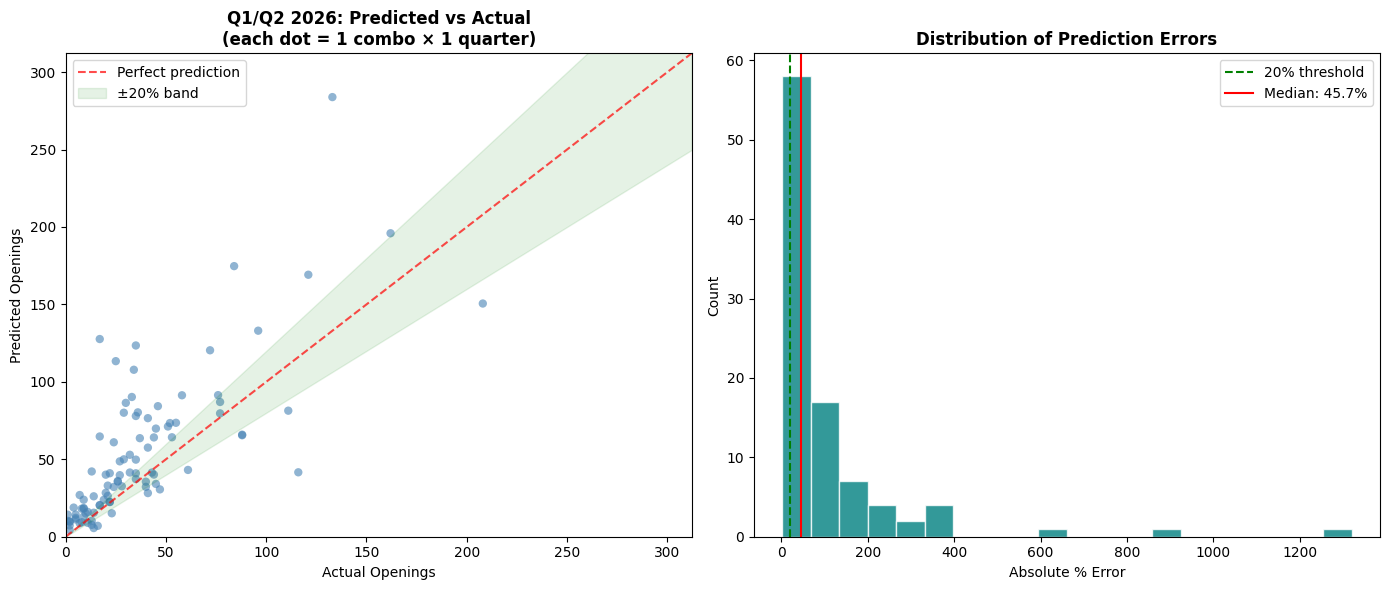


══════════════════════════════════════════════════════════════════════
EXPORT COMPLETE
══════════════════════════════════════════════════════════════════════

✅ Saved: c:\Users\serveradmin\Desktop\resume-processing-system\data\forecasts_2026.pkl
   Shape: (492, 17)
   Columns: ['combo_key', 'region', 'role_cluster', 'quarter', 'forecast', 'ci_lower', 'ci_upper', 'tier', 'forecast_method', 'low_volume_flag', 'location', 'allocation_pct', 'loc_forecast', 'loc_ci_lower', 'loc_ci_upper', 'confidence', 'is_full_granularity']

══════════════════════════════════════════════════════════════════════
LEADERSHIP HEADLINE
══════════════════════════════════════════════════════════════════════

  📊 Validation accuracy on Q1/Q2 2026 holdout:
     • Median error: 45.7%
     • 17% of predictions within ±20% of actual
     • 32% of predictions within ±30% of actual

  📈 Forecast coverage:
     • 51 role-level combos forecasted
     • 11 location-level direct forecasts
     • 61 unique locations with pr

In [31]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Validation Against Q1/Q2 2026 Actuals
#
# BASELINE — fixed reference point. NOT affected by Group 1/2/3
# forecast adjustments. Uses original models trained on 2022-2025.
# Train on 2022Q1-2025Q4, predict Q1+Q2 2026, compare to
# real numbers. This is the credibility metric for leadership.
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

print("BASELINE VALIDATION (frozen — uses original 2022-2025 models, not recency-adjusted)")
print("─"*75)

val_quarters = [pd.Period('2026Q1', freq='Q'), pd.Period('2026Q2', freq='Q')]

# Get actual Q1/Q2 2026 openings per combo (use range comparison for Period compatibility)
val_start = pd.Period('2026Q1', freq='Q')
val_end = pd.Period('2026Q2', freq='Q')
actuals_2026 = ts_data[(ts_data['quarter'] >= val_start) & (ts_data['quarter'] <= val_end)].copy()

# Use actual Period objects from data for comparisons (avoids freq mismatch)
actual_val_quarters = sorted(actuals_2026['quarter'].unique())
print(f"DEBUG: actuals_2026 has {len(actuals_2026)} rows, quarters: {[str(q) for q in actual_val_quarters]}")

val_results = []

for combo, info in models.items():
    tier = info['tier']
    fitted = info['model']
    train = info['train_data']
    exog_cols = info['exog_cols']
    
    # Get actuals
    combo_actuals = actuals_2026[actuals_2026['combo_key'] == combo]
    if len(combo_actuals) == 0:
        continue
    
    # Predict Q1/Q2 2026
    try:
        n_steps = len(actual_val_quarters)
        if tier == 'Tier 1':
            future_exog = []
            for vq in actual_val_quarters:
                row = {}
                # Use range comparison for UNRATE lookup too
                ur_match = unrate_qtr[(unrate_qtr['quarter'] >= vq) & (unrate_qtr['quarter'] <= vq)]['unrate']
                row['unrate'] = ur_match.values[0] if len(ur_match) > 0 else latest_unrate
                row['Q1'] = 1 if vq.quarter == 1 else 0
                row['Q2'] = 1 if vq.quarter == 2 else 0
                row['Q3'] = 1 if vq.quarter == 3 else 0
                if info['use_fills']:
                    row['fills_lagged'] = train['fills'].iloc[-1]
                future_exog.append(row)
            
            X_val = pd.DataFrame(future_exog)[exog_cols].values.astype(float)
            preds = np.asarray(fitted.get_forecast(steps=n_steps, exog=X_val).predicted_mean)
        else:
            preds = np.asarray(fitted.forecast(steps=n_steps))
        
        # Guardrail: floor at 40% of recent avg, cap at 2.5×
        recent_avg = train['openings'].iloc[-4:].mean()
        preds = np.clip(preds, recent_avg * 0.4, recent_avg * 2.5)
        
        for i, vq in enumerate(actual_val_quarters):
            actual_row = combo_actuals[(combo_actuals['quarter'] >= vq) & (combo_actuals['quarter'] <= vq)]
            if len(actual_row) == 0:
                continue
            actual = actual_row['openings'].values[0]
            pred = preds[i]
            
            val_results.append({
                'combo_key': combo,
                'tier': tier,
                'quarter': vq,
                'actual': actual,
                'predicted': pred,
                'error': pred - actual,
                'abs_error': abs(pred - actual),
                'pct_error': abs(pred - actual) / max(actual, 1) * 100,
            })
    except:
        continue

val_df = pd.DataFrame(val_results)

print("═"*70)
print("VALIDATION: Q1/Q2 2026 — Predictions vs Actuals")
print("═"*70)

if len(val_df) > 0:
    print(f"\nCombos validated: {val_df['combo_key'].nunique()}")
    print(f"Total observations: {len(val_df)}")
    
    print(f"\n── Overall Accuracy: ──")
    print(f"  Median MAPE: {val_df['pct_error'].median():.1f}%")
    print(f"  Mean MAPE:   {val_df['pct_error'].mean():.1f}%")
    print(f"  Median MAE:  {val_df['abs_error'].median():.1f} openings")
    
    # Within 20% accuracy
    within_20 = (val_df['pct_error'] <= 20).mean() * 100
    within_30 = (val_df['pct_error'] <= 30).mean() * 100
    print(f"  Within ±20%: {within_20:.1f}% of predictions")
    print(f"  Within ±30%: {within_30:.1f}% of predictions")
    
    # By tier
    print(f"\n── By Tier: ──")
    for tier in ['Tier 1', 'Tier 2']:
        tier_val = val_df[val_df['tier'] == tier]
        if len(tier_val) > 0:
            print(f"  {tier}: median MAPE={tier_val['pct_error'].median():.1f}%, "
                  f"within ±20%: {(tier_val['pct_error'] <= 20).mean()*100:.0f}%")
    
    # By quarter
    print(f"\n── By Quarter: ──")
    for vq in val_quarters:
        qtr_val = val_df[val_df['quarter'] == vq]
        if len(qtr_val) > 0:
            print(f"  {vq}: median MAPE={qtr_val['pct_error'].median():.1f}%, n={len(qtr_val)}")
    
    # Scatter plot: predicted vs actual
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot A: scatter
    ax = axes[0]
    ax.scatter(val_df['actual'], val_df['predicted'], alpha=0.6, c='steelblue', edgecolors='none')
    max_val = max(val_df['actual'].max(), val_df['predicted'].max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='Perfect prediction')
    ax.fill_between([0, max_val], [0, max_val*0.8], [0, max_val*1.2], alpha=0.1, color='green', label='±20% band')
    ax.set_xlabel('Actual Openings')
    ax.set_ylabel('Predicted Openings')
    ax.set_title('Q1/Q2 2026: Predicted vs Actual\n(each dot = 1 combo × 1 quarter)', fontweight='bold')
    ax.legend()
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    
    # Plot B: MAPE distribution
    ax = axes[1]
    ax.hist(val_df['pct_error'], bins=20, color='teal', edgecolor='white', alpha=0.8)
    ax.axvline(x=20, color='green', linestyle='--', label='20% threshold')
    ax.axvline(x=val_df['pct_error'].median(), color='red', linestyle='-', label=f'Median: {val_df["pct_error"].median():.1f}%')
    ax.set_xlabel('Absolute % Error')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Prediction Errors', fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Export final forecasts
    export_path = os.path.join(data_dir, 'forecasts_2026.pkl')
    final_forecasts.to_pickle(export_path)
    
    print(f"\n{'═'*70}")
    print("EXPORT COMPLETE")
    print(f"{'═'*70}")
    print(f"\n✅ Saved: {export_path}")
    print(f"   Shape: {final_forecasts.shape}")
    print(f"   Columns: {final_forecasts.columns.tolist()}")
    
    # Leadership headline
    print(f"\n{'═'*70}")
    print("LEADERSHIP HEADLINE")
    print(f"{'═'*70}")
    print(f"\n  📊 Validation accuracy on Q1/Q2 2026 holdout:")
    print(f"     • Median error: {val_df['pct_error'].median():.1f}%")
    print(f"     • {within_20:.0f}% of predictions within ±20% of actual")
    print(f"     • {within_30:.0f}% of predictions within ±30% of actual")
    print(f"\n  📈 Forecast coverage:")
    print(f"     • {len(models)} role-level combos forecasted")
    print(f"     • {len(full_gran_segments)} location-level direct forecasts")
    print(f"     • {final_forecasts['location'].nunique()} unique locations with predictions")
else:
    print("\n⚠️  No Q1/Q2 2026 actuals found for validation.")

In [13]:
# ═══════════════════════════════════════════════════════════════
# DATA COMPLETENESS DIAGNOSTIC
#
# Is Q2 2026 undercounted because data was extracted mid-May
# (before the quarter finished)?
# ═══════════════════════════════════════════════════════════════

# Overall quarterly record counts
quarterly_counts = df.groupby(df['issue_date'].dt.to_period('Q')).size()
print("── Last 8 quarters (record counts): ──")
print(quarterly_counts.tail(8).to_string())

# Same-quarter year-over-year comparison
print("\n── Year-over-Year by Quarter: ──")
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    print(f"\n  {q} comparison across years:")
    for yr in [2023, 2024, 2025, 2026]:
        period = pd.Period(f'{yr}{q}', freq='Q')
        if period in quarterly_counts.index:
            print(f"    {period}: {quarterly_counts[period]:>6,} records")

# What's the latest issue_date in the data?
print(f"\n── Data extraction boundary: ──")
print(f"  Latest issue_date: {df['issue_date'].max()}")
print(f"  Latest issue_date month: {df['issue_date'].max().strftime('%Y-%m')}")

# Monthly breakdown of Q2 2026 specifically
q2_2026 = df[(df['issue_date'] >= '2026-04-01') & (df['issue_date'] < '2026-07-01')]
print(f"\n── Q2 2026 monthly breakdown: ──")
monthly = q2_2026.groupby(q2_2026['issue_date'].dt.to_period('M')).size()
for m, count in monthly.items():
    print(f"    {m}: {count:>5,} records")

# Compare to Q2 2025 monthly pattern
q2_2025 = df[(df['issue_date'] >= '2025-04-01') & (df['issue_date'] < '2025-07-01')]
print(f"\n── Q2 2025 monthly breakdown (reference): ──")
monthly_25 = q2_2025.groupby(q2_2025['issue_date'].dt.to_period('M')).size()
for m, count in monthly_25.items():
    print(f"    {m}: {count:>5,} records")

── Last 8 quarters (record counts): ──
issue_date
2024Q3    2598
2024Q4    2291
2025Q1    2855
2025Q2    2898
2025Q3    2322
2025Q4    1621
2026Q1    1976
2026Q2    1399
Freq: Q-DEC

── Year-over-Year by Quarter: ──

  Q1 comparison across years:
    2023Q1:  2,893 records
    2024Q1:  2,461 records
    2025Q1:  2,855 records
    2026Q1:  1,976 records

  Q2 comparison across years:
    2023Q2:  2,624 records
    2024Q2:  2,265 records
    2025Q2:  2,898 records
    2026Q2:  1,399 records

  Q3 comparison across years:
    2023Q3:  2,515 records
    2024Q3:  2,598 records
    2025Q3:  2,322 records

  Q4 comparison across years:
    2023Q4:  2,180 records
    2024Q4:  2,291 records
    2025Q4:  1,621 records

── Data extraction boundary: ──
  Latest issue_date: 2026-06-05 08:16:30
  Latest issue_date month: 2026-06

── Q2 2026 monthly breakdown: ──
    2026-04:   651 records
    2026-05:   644 records
    2026-06:   104 records

── Q2 2025 monthly breakdown (reference): ──
    2025-04:

═══════════════════════════════════════════════════════════════════════════
Q1 2026 COMBO-LEVEL BREAKDOWN (Q2 excluded — data incomplete)
═══════════════════════════════════════════════════════════════════════════

── Q1 2026 Only (honest validation): ──
  Combos: 49
  Median MAPE: 41.8%
  Within ±20%: 14%
  Within ±30%: 33%
  Over-predicted: 73% of combos

── YoY Contraction (Q1 2026 / Q1 2025): ──
  Median ratio: 0.698 (1.0 = flat, <1.0 = contraction)
  Mean ratio:   0.820
  Std dev:      0.764
  Range:        [0.015 – 5.400]
  IQR:          [0.448 – 0.885]

  Combos with ratio in [0.5–1.0]: 51%
  Combos growing (ratio > 1.0): 11
  Combos contracting >50% (ratio < 0.5): 13

── All combos (sorted by volume): ──
Combo                                  Tier    Q1-25   Q1-26   Pred    YoY     MAPE    Dir
──────────────────────────────────────────────────────────────────────────────────────────
US | Operations - General              Tier 1    168    208    151   1.24   27.6%  UNDER
US | En

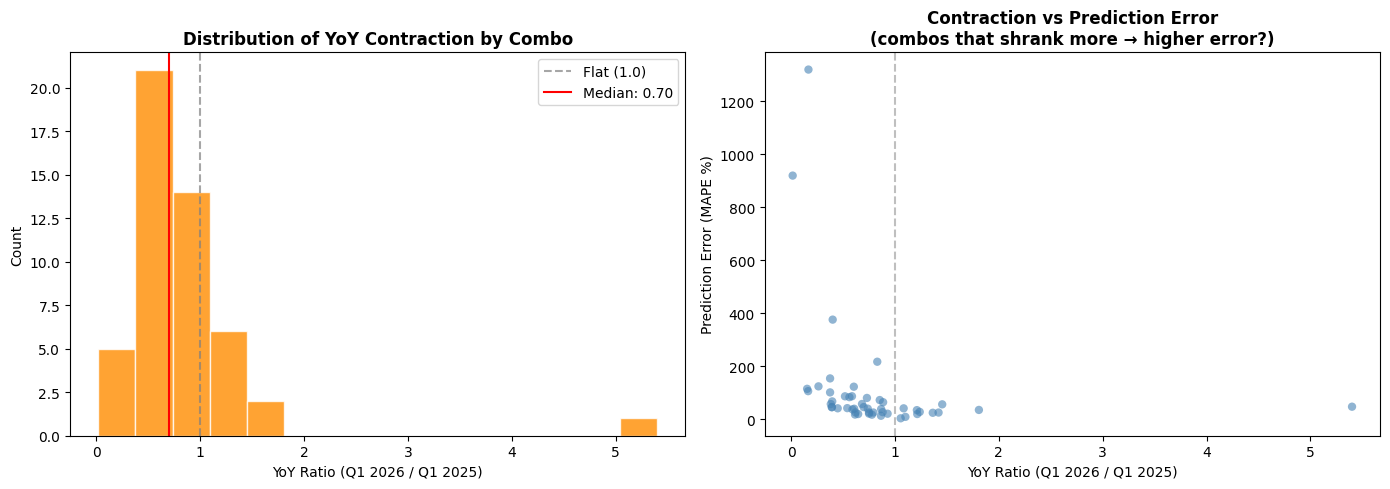


═══════════════════════════════════════════════════════════════════════════
POTENTIAL ADJUSTMENT FACTOR
═══════════════════════════════════════════════════════════════════════════

  If contraction is uniform, a single scalar correction of ~0.70
  applied to Q3/Q4 2026 forecasts would reduce systematic over-prediction.
  IQR spread: 0.437 — too dispersed for single factor


In [14]:
# ═══════════════════════════════════════════════════════════════
# COMBO-LEVEL Q1 2026 VALIDATION + YoY CONTRACTION RATIOS
#
# Q2 2026 excluded (data incomplete — extracted June 5).
# Focus: Is over-prediction uniform (macro shift) or concentrated?
# ═══════════════════════════════════════════════════════════════

# Filter validation to Q1 2026 only
q1_val = val_df[val_df['quarter'].apply(lambda x: x.quarter == 1)].copy()

# Get Q1 2025 actuals for YoY ratio
q1_2025_start = pd.Period('2025Q1', freq='Q')
actuals_q1_2025 = ts_data[(ts_data['quarter'] >= q1_2025_start) & (ts_data['quarter'] <= q1_2025_start)]

# Build combo breakdown
combo_breakdown = []
for _, row in q1_val.iterrows():
    combo = row['combo_key']
    
    # Q1 2025 actual for this combo
    q1_25 = actuals_q1_2025[actuals_q1_2025['combo_key'] == combo]
    q1_25_openings = q1_25['openings'].values[0] if len(q1_25) > 0 else np.nan
    
    # YoY ratio: Q1 2026 / Q1 2025
    yoy_ratio = row['actual'] / q1_25_openings if q1_25_openings > 0 else np.nan
    
    combo_breakdown.append({
        'combo_key': combo,
        'tier': row['tier'],
        'q1_2026_actual': row['actual'],
        'q1_2026_predicted': row['predicted'],
        'q1_2025_actual': q1_25_openings,
        'yoy_ratio': yoy_ratio,
        'pct_error': row['pct_error'],
        'error_direction': 'OVER' if row['error'] > 0 else 'UNDER',
    })

cb_df = pd.DataFrame(combo_breakdown).sort_values('q1_2026_actual', ascending=False)

# ── Summary stats ──
print("═"*75)
print("Q1 2026 COMBO-LEVEL BREAKDOWN (Q2 excluded — data incomplete)")
print("═"*75)

q1_only_mape = q1_val['pct_error'].median()
q1_within_20 = (q1_val['pct_error'] <= 20).mean() * 100
q1_within_30 = (q1_val['pct_error'] <= 30).mean() * 100
over_pct = (cb_df['error_direction'] == 'OVER').mean() * 100

print(f"\n── Q1 2026 Only (honest validation): ──")
print(f"  Combos: {len(cb_df)}")
print(f"  Median MAPE: {q1_only_mape:.1f}%")
print(f"  Within ±20%: {q1_within_20:.0f}%")
print(f"  Within ±30%: {q1_within_30:.0f}%")
print(f"  Over-predicted: {over_pct:.0f}% of combos")

# ── YoY contraction analysis ──
valid_yoy = cb_df.dropna(subset=['yoy_ratio'])
print(f"\n── YoY Contraction (Q1 2026 / Q1 2025): ──")
print(f"  Median ratio: {valid_yoy['yoy_ratio'].median():.3f} (1.0 = flat, <1.0 = contraction)")
print(f"  Mean ratio:   {valid_yoy['yoy_ratio'].mean():.3f}")
print(f"  Std dev:      {valid_yoy['yoy_ratio'].std():.3f}")
print(f"  Range:        [{valid_yoy['yoy_ratio'].min():.3f} – {valid_yoy['yoy_ratio'].max():.3f}]")
print(f"  IQR:          [{valid_yoy['yoy_ratio'].quantile(0.25):.3f} – {valid_yoy['yoy_ratio'].quantile(0.75):.3f}]")

# Is it uniform?
tight_band = ((valid_yoy['yoy_ratio'] >= 0.5) & (valid_yoy['yoy_ratio'] <= 1.0)).mean() * 100
print(f"\n  Combos with ratio in [0.5–1.0]: {tight_band:.0f}%")
print(f"  Combos growing (ratio > 1.0): {(valid_yoy['yoy_ratio'] > 1.0).sum()}")
print(f"  Combos contracting >50% (ratio < 0.5): {(valid_yoy['yoy_ratio'] < 0.5).sum()}")

# ── Full combo table ──
print(f"\n── All combos (sorted by volume): ──")
print(f"{'Combo':<38} {'Tier':<7} {'Q1-25':<7} {'Q1-26':<7} {'Pred':<7} {'YoY':<7} {'MAPE':<7} {'Dir'}")
print("─"*90)
for _, r in cb_df.iterrows():
    yoy_str = f"{r['yoy_ratio']:.2f}" if not np.isnan(r['yoy_ratio']) else "N/A"
    print(f"{r['combo_key'][:37]:<38} {r['tier']:<7} "
          f"{r['q1_2025_actual']:>5.0f}  {r['q1_2026_actual']:>5.0f}  {r['q1_2026_predicted']:>5.0f}  "
          f"{yoy_str:>5}  {r['pct_error']:>5.1f}%  {r['error_direction']}")

# ── Histogram of YoY ratios ──
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(valid_yoy['yoy_ratio'], bins=15, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='Flat (1.0)')
ax.axvline(x=valid_yoy['yoy_ratio'].median(), color='red', linestyle='-', 
           label=f'Median: {valid_yoy["yoy_ratio"].median():.2f}')
ax.set_xlabel('YoY Ratio (Q1 2026 / Q1 2025)')
ax.set_ylabel('Count')
ax.set_title('Distribution of YoY Contraction by Combo', fontweight='bold')
ax.legend()

ax = axes[1]
ax.scatter(cb_df['yoy_ratio'], cb_df['pct_error'], alpha=0.6, c='steelblue', edgecolors='none')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('YoY Ratio (Q1 2026 / Q1 2025)')
ax.set_ylabel('Prediction Error (MAPE %)')
ax.set_title('Contraction vs Prediction Error\n(combos that shrank more → higher error?)', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Potential adjustment factor ──
median_yoy = valid_yoy['yoy_ratio'].median()
print(f"\n{'═'*75}")
print(f"POTENTIAL ADJUSTMENT FACTOR")
print(f"{'═'*75}")
print(f"\n  If contraction is uniform, a single scalar correction of ~{median_yoy:.2f}")
print(f"  applied to Q3/Q4 2026 forecasts would reduce systematic over-prediction.")
print(f"  IQR spread: {valid_yoy['yoy_ratio'].quantile(0.75) - valid_yoy['yoy_ratio'].quantile(0.25):.3f} — "
      f"{'tight enough for single factor' if (valid_yoy['yoy_ratio'].quantile(0.75) - valid_yoy['yoy_ratio'].quantile(0.25)) < 0.4 else 'too dispersed for single factor'}")

In [26]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Group Assignment Summary
#
# Shows all 51 combos: recency ratio, group, forecast method.
# Sanity check against the earlier YoY breakdown.
# ═══════════════════════════════════════════════════════════════

print("═"*80)
print("FORECAST GROUP ASSIGNMENTS (all 51 combos)")
print("═"*80)

# Build summary table
group_summary = []
for combo in viable_combos:
    group = forecast_group.get(combo, 'Unknown')
    ratio = recency_ratios.get(combo, np.nan)
    tier = tier_map.get(combo, '?')
    
    if 'Group 3' in group:
        method = f"Override: {group3_overrides.get(combo, 0):.0f}/qtr"
    elif combo in forecast_models:
        method = forecast_models[combo].get('group', '?')
    else:
        method = 'Not fitted'
    
    group_summary.append({
        'combo_key': combo,
        'tier': tier,
        'recency_ratio': ratio,
        'group': group,
    })

gs_df = pd.DataFrame(group_summary).sort_values('recency_ratio', ascending=True)

# Summary counts
print(f"\n── Group Counts: ──")
for g in ['Group 1 - Stable', 'Group 2 - Moderate contraction', 'Group 3 - Severe collapse']:
    count = sum(1 for x in gs_df['group'] if g in x)
    combos_in_group = gs_df[gs_df['group'] == g]['combo_key'].tolist()
    print(f"  {g}: {count} combos")

# Full table
print(f"\n── Full Assignment Table (sorted by recency ratio, ascending): ──")
print(f"{'Combo':<40} {'Tier':<7} {'Ratio':<7} {'Group'}")
print("─"*80)
for _, r in gs_df.iterrows():
    ratio_str = f"{r['recency_ratio']:.3f}" if not np.isnan(r['recency_ratio']) else "N/A"
    group_short = r['group'].replace('Group 1 - ', 'G1: ').replace('Group 2 - ', 'G2: ').replace('Group 3 - ', 'G3: ')
    print(f"{r['combo_key'][:39]:<40} {r['tier']:<7} {ratio_str:>6}  {group_short}")

# Compare to Cell 11's YoY breakdown
print(f"\n── Cross-check with Q1 YoY analysis: ──")
print(f"  Combos contracting >50% (YoY < 0.5): 13 (from Cell 11)")
print(f"  Combos in Group 3 (recency < 0.40): {sum(1 for x in gs_df['group'] if 'Group 3' in x)}")
print(f"  (Difference = different metrics: YoY Q1 only vs last-2Q/prior-4Q ratio)")

════════════════════════════════════════════════════════════════════════════════
FORECAST GROUP ASSIGNMENTS (all 51 combos)
════════════════════════════════════════════════════════════════════════════════

── Group Counts: ──
  Group 1 - Stable: 22 combos
  Group 2 - Moderate contraction: 22 combos
  Group 3 - Severe collapse: 7 combos

── Full Assignment Table (sorted by recency ratio, ascending): ──
Combo                                    Tier    Ratio   Group
────────────────────────────────────────────────────────────────────────────────
US | Healthcare / Clinical               Tier 2   0.108  G3: Severe collapse
IN | Design Engineer                     Tier 2   0.211  G3: Severe collapse
US | Content Strategist                  Tier 2   0.235  G3: Severe collapse
US | IT Analyst                          Tier 2   0.240  G3: Severe collapse
IN | ERP Consultant                      Tier 2   0.288  G3: Severe collapse
IN | Developer                           Tier 1   0.302  G3: Sever